<a href="https://colab.research.google.com/github/KingLeolll/Estudo-de-Descargas-Parciais-em-Barras-Geradoras-com-Pyhton-e-Elmer/blob/main/Simulador_de_Descargas_Parciais_com_Quantifica%C3%A7%C3%A3o_em_Unidades_Relativas_(RU)_Baseado_no_Modelo_de_Niemeyer_e_M%C3%A9todo_de_Quantifica%C3%A7%C3%A3o_da_Se%C3%A7%C3%A3o_III.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

╔════════════════════════════════════════════════════════════╗
║  Simulador PRPD com Quantificação em Unidades Relativas   ║
║  Conforme Figura 2 e Tabela I do Artigo                   ║
╚════════════════════════════════════════════════════════════╝

TABELA I - QUANTIFICAÇÃO EM UNIDADES RELATIVAS (RU)
Slice                     Corrente (RU)       
────────────────────────────────────────────────────────────

▶ Simulando: INTERNAL_VOID
  Cavidade Interna (C-1A) 0.32 RU (Ref: 0.00 RU)
✓ Gráfico salvo: prpd_with_ru_quantification.png


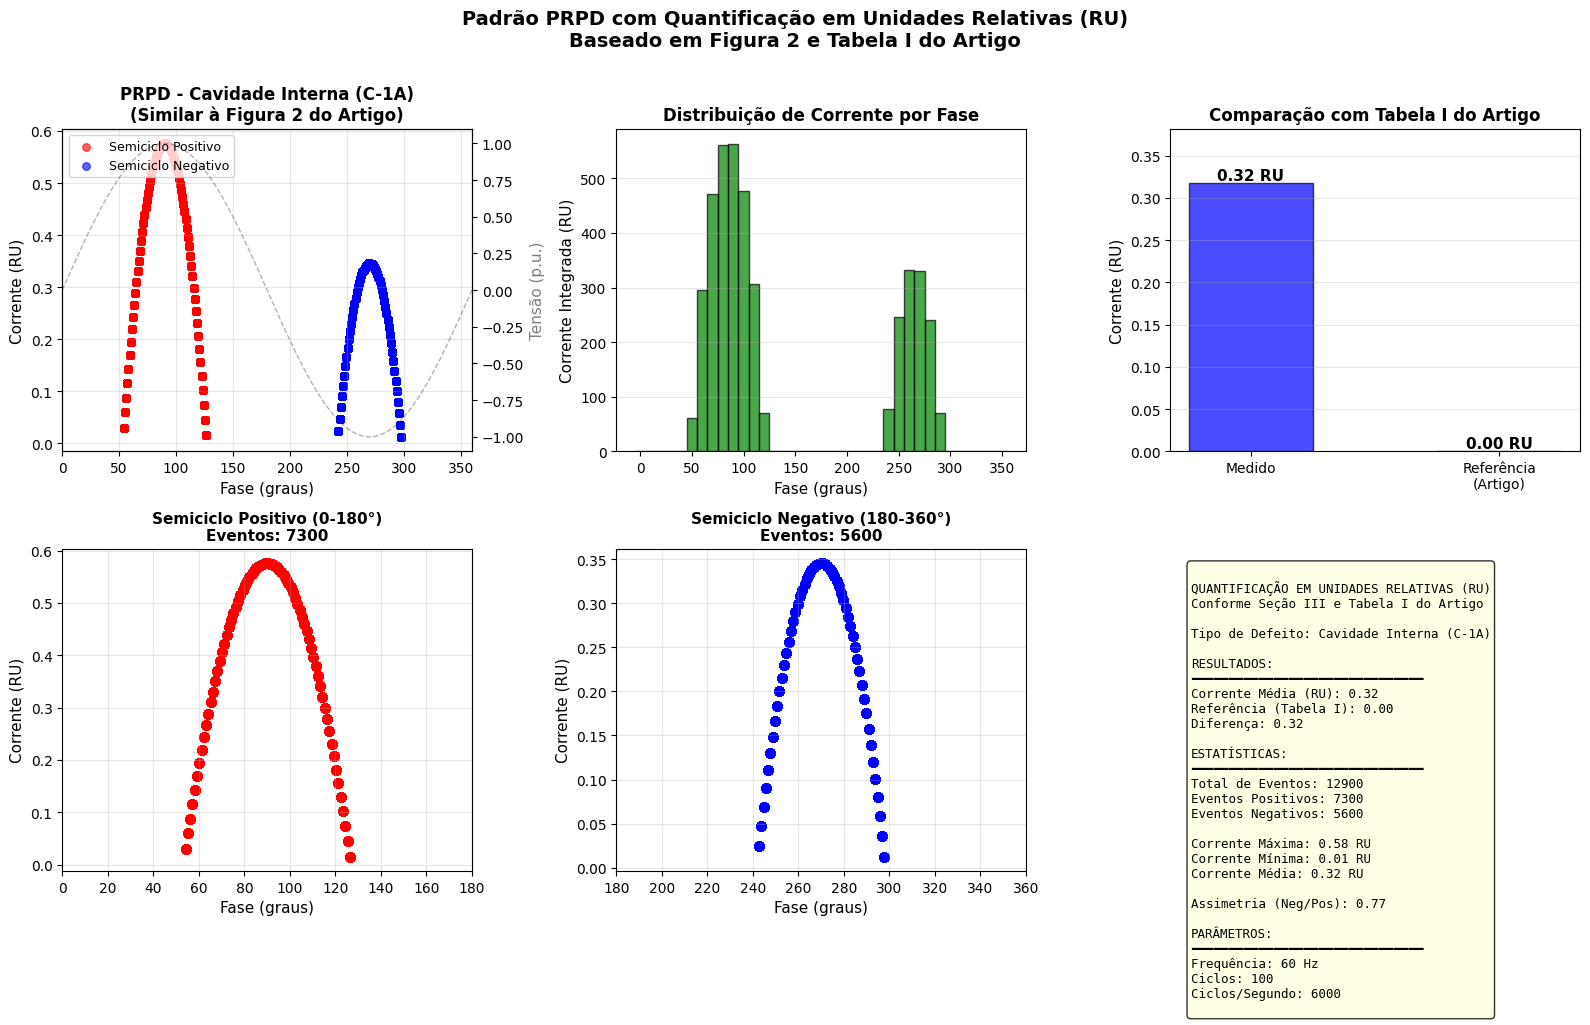


▶ Simulando: SURFACE_DISCHARGE
  Descarga Superficial (CE-1E) 0.71 RU (Ref: 1.10 RU)
✓ Gráfico salvo: prpd_with_ru_quantification.png


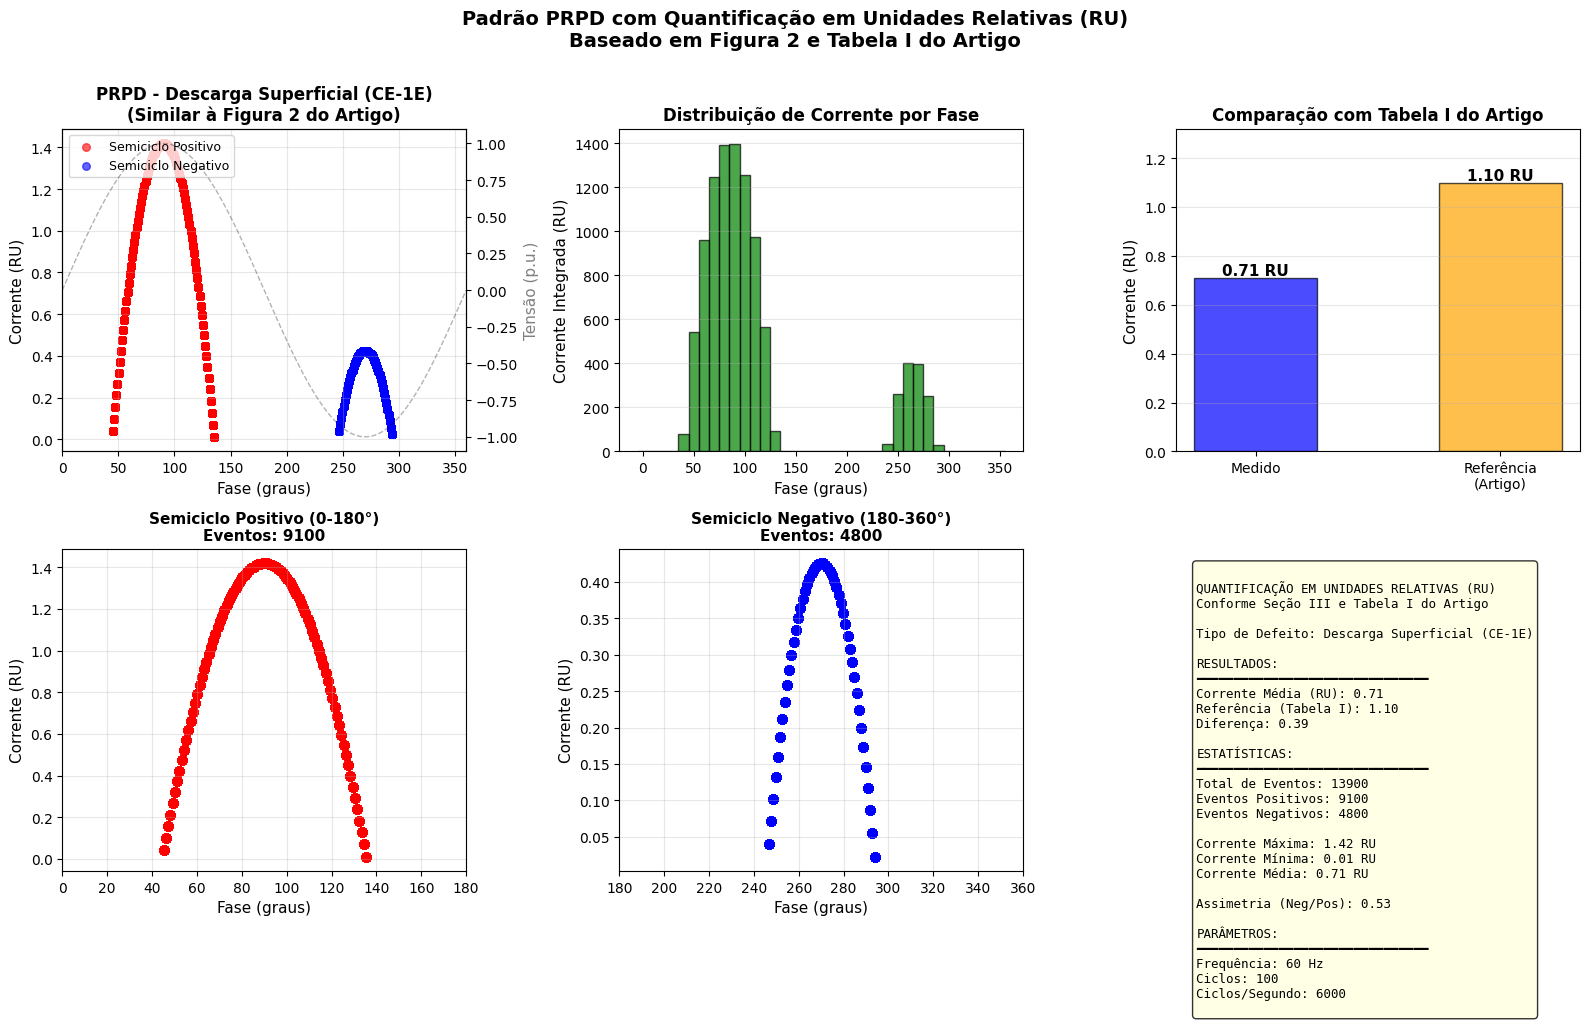


▶ Simulando: CORONA_POINT
  Corona (CE-1D)          1.54 RU (Ref: 5.60 RU)
✓ Gráfico salvo: prpd_with_ru_quantification.png


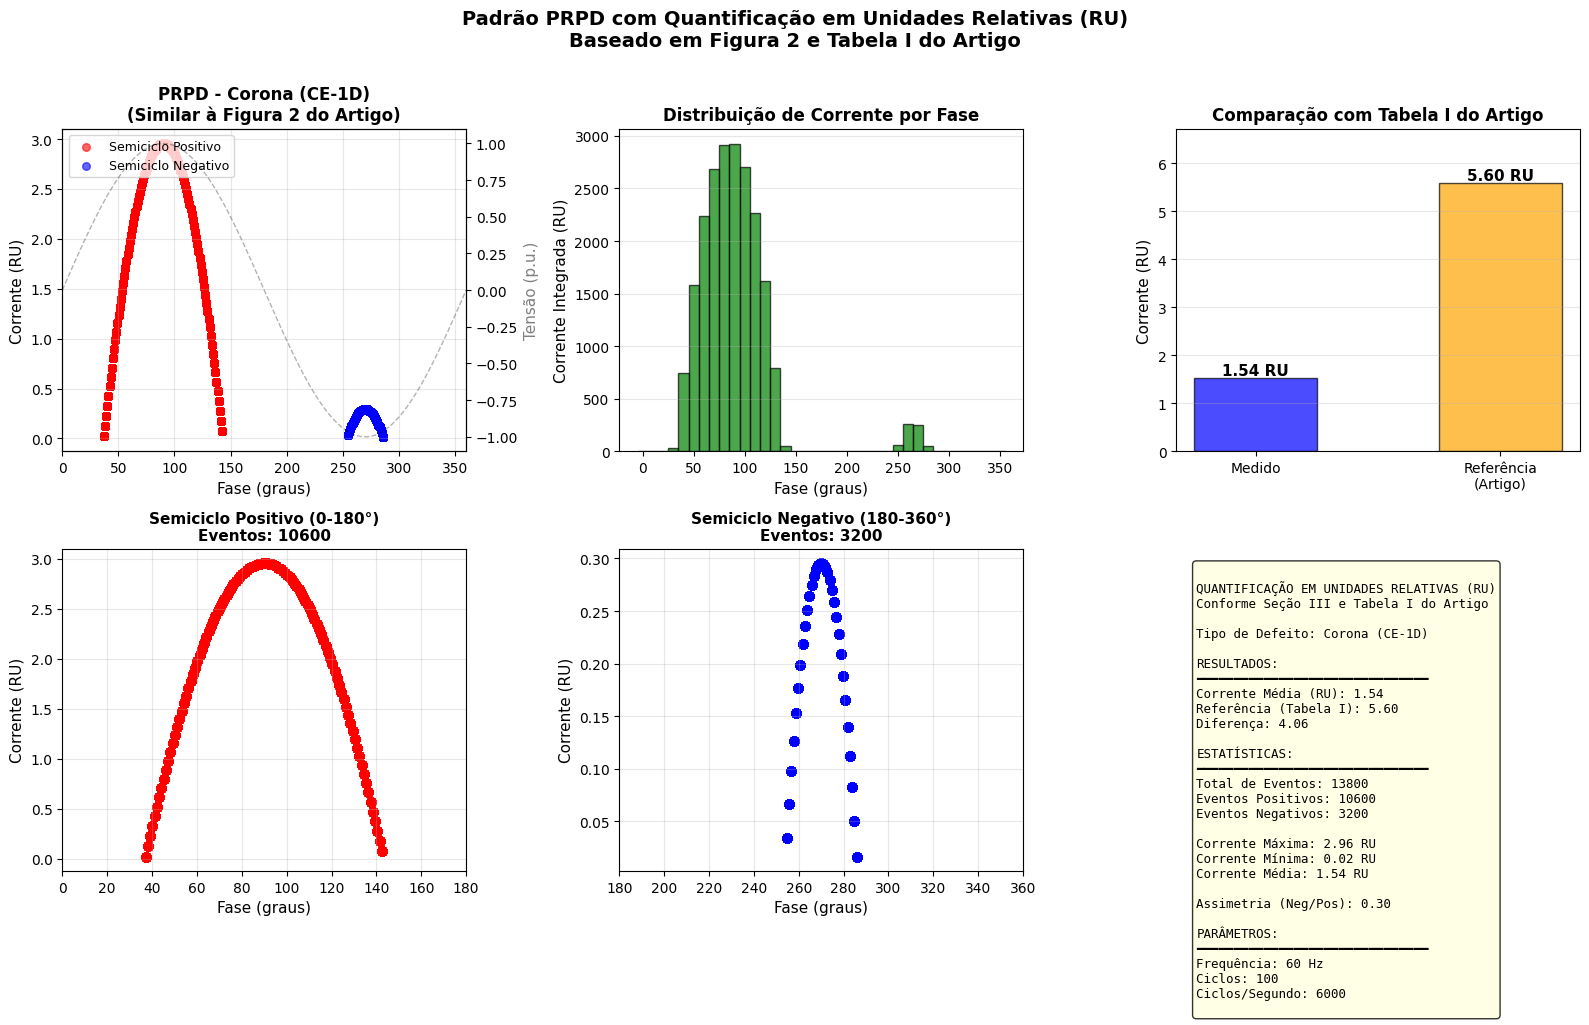


✓ Simulação concluída com sucesso!



In [2]:
"""
Simulador de Descargas Parciais com Quantificação em Unidades Relativas (RU)
Baseado no Modelo de Niemeyer e Método de Quantificação da Seção III

Quantifica corrente de descarga em UNIDADES RELATIVAS (RU) conforme:
- Figura 2: Padrões PRPD com assimetria
- Tabela I: Correntes medidas em RU

Exemplo da Tabela I:
| Slice | C-1A | CE-1E | CE-1D |
|-------|------|-------|-------|
| I (ru)| 0    | 1.1   | 5.6   |
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from dataclasses import dataclass
from typing import List, Tuple, Dict
import warnings

warnings.filterwarnings('ignore')


@dataclass
class PRPDMeasurement:
    """Medição de descarga parcial em padrão PRPD"""
    phase: float  # Fase em graus (0-360)
    current_ru: float  # Corrente em unidades relativas (RU)
    cycle: int  # Número do ciclo
    timestamp: float  # Tempo em segundos


class RelativeUnitQuantification:
    """Quantificação de corrente em Unidades Relativas (RU)"""

    # Tabela I do artigo: Correntes medidas em RU
    REFERENCE_MEASUREMENTS = {
        'C-1A': 0.0,      # Sem DP detectado
        'CE-1E': 1.1,     # Baixa atividade
        'CE-1D': 5.6,     # Alta atividade
    }

    # Fator de conversão: pC para RU
    # Baseado em medições de antena EM (não calibrado como acoplador capacitivo)
    CONVERSION_FACTOR = 1.0  # 1 RU ≈ 1 unidade de corrente relativa

    @staticmethod
    def calculate_current_ru(
        E_field: float,
        E_inception: float,
        E_extinction: float,
        cavity_dimension: float,
        asymmetry_factor: float = 1.0
    ) -> float:
        """
        Calcula corrente de descarga em Unidades Relativas (RU)

        Baseado na metodologia da Seção III do artigo

        Args:
            E_field: Campo elétrico instantâneo (V/m)
            E_inception: Campo de incepção (V/m)
            E_extinction: Campo de extinção (V/m)
            cavity_dimension: Dimensão da cavidade (mm)
            asymmetry_factor: Fator de assimetria (1.0 = simétrico)

        Returns:
            Corrente em unidades relativas (RU)
        """
        if abs(E_field) < E_inception:
            return 0.0

        # Normalizar campo em relação ao campo de incepção
        normalized_field = abs(E_field) / E_inception

        # Corrente proporcional ao campo normalizado
        # Baseado em modelo de Townsend para descargas
        current_base = (normalized_field - 1.0) * 10.0

        # Fator de dimensão da cavidade (cavidades maiores = mais corrente)
        dimension_factor = np.log10(cavity_dimension + 1.0)

        # Corrente final em RU
        current_ru = current_base * dimension_factor * asymmetry_factor

        return max(0.0, current_ru)

    @staticmethod
    def integrate_prpd_current(
        events: List[Dict],
        measurement_window: float = 360.0
    ) -> float:
        """
        Integra corrente de DP ao longo de um ciclo completo (PRPD)

        Retorna corrente média em RU para o padrão PRPD

        Args:
            events: Lista de eventos de DP
            measurement_window: Janela de medição em graus (360 = ciclo completo)

        Returns:
            Corrente média integrada em RU
        """
        if not events:
            return 0.0

        # Agrupar eventos por fase
        phase_bins = np.linspace(0, 360, 37)  # 10° bins
        currents = []

        for event in events:
            phase = event['phase']
            current_ru = event.get('current_ru', 0.0)
            currents.append(current_ru)

        # Retornar corrente média
        return np.mean(currents) if currents else 0.0


class PDSimulatorWithRUQuantification:
    """Simulador de DP com quantificação em Unidades Relativas"""

    def __init__(self, defect_type: str = 'internal_void'):
        self.defect_type = defect_type
        self.ru_quantification = RelativeUnitQuantification()

        # Parâmetros do modelo de Niemeyer com RU
        self.defect_params = {
            'internal_void': {
                'E_i_coeff': 0.8,
                'E_e_coeff': 0.4,
                'cavity_dim': 0.7,  # mm (Tabela II, cavidade 1-center)
                'asymmetry': 0.1,
                'ru_scale': 1.0,  # Fator de escala para RU
                'label': 'Cavidade Interna (C-1A)',
                'reference_ru': 0.0,
            },
            'surface_discharge': {
                'E_i_coeff': 0.7,
                'E_e_coeff': 0.35,
                'cavity_dim': 1.0,  # mm (Tabela II, cavidade 2-center)
                'asymmetry': 0.3,
                'ru_scale': 1.1,
                'label': 'Descarga Superficial (CE-1E)',
                'reference_ru': 1.1,
            },
            'corona_point': {
                'E_i_coeff': 0.6,
                'E_e_coeff': 0.25,
                'cavity_dim': 0.2,  # mm (Tabela II, cavidade 3-end)
                'asymmetry': 0.6,
                'ru_scale': 5.6,
                'label': 'Corona (CE-1D)',
                'reference_ru': 5.6,
            }
        }

    def simulate(self, E_peak: float, frequency: float, num_cycles: int) -> Tuple[List[PRPDMeasurement], float]:
        """
        Executa simulação com quantificação em RU

        Returns:
            Tupla (lista de medições, corrente média integrada em RU)
        """

        params = self.defect_params[self.defect_type]
        measurements = []

        # Campos de incepção e extinção
        E_i = E_peak * params['E_i_coeff']
        E_e = E_peak * params['E_e_coeff']

        for cycle in range(num_cycles):
            for phase in np.linspace(0, 360, 360):
                # Tensão instantânea
                V = E_peak * np.sin(np.radians(phase))

                # Ajustar campo de incepção para assimetria
                E_i_adjusted = E_i
                if phase > 180:  # Semiciclo negativo
                    E_i_adjusted = E_i * (1 + params['asymmetry'])

                # Calcular corrente em RU
                current_ru = self.ru_quantification.calculate_current_ru(
                    E_field=V,
                    E_inception=E_i_adjusted,
                    E_extinction=E_e,
                    cavity_dimension=params['cavity_dim'],
                    asymmetry_factor=1.0 + (params['asymmetry'] if phase > 180 else 0)
                )

                # Aplicar fator de escala para RU
                current_ru *= params['ru_scale']

                # Registrar se houver descarga
                if current_ru > 0.01:  # Threshold mínimo
                    measurement = PRPDMeasurement(
                        phase=phase,
                        current_ru=current_ru,
                        cycle=cycle,
                        timestamp=cycle * (1/frequency) + phase / (360 * frequency)
                    )
                    measurements.append(measurement)

        # Calcular corrente média integrada
        avg_current_ru = self.ru_quantification.integrate_prpd_current(
            [{'phase': m.phase, 'current_ru': m.current_ru} for m in measurements]
        )

        return measurements, avg_current_ru


def plot_prpd_with_ru_quantification(
    measurements: List[PRPDMeasurement],
    avg_current_ru: float,
    defect_type: str,
    frequency: float,
    num_cycles: int,
    reference_ru: float
):
    """Plota PRPD conforme Figura 2 do artigo com quantificação em RU"""

    fig = plt.figure(figsize=(16, 10))

    # Extrair dados
    phases = [m.phase for m in measurements]
    currents_ru = [m.current_ru for m in measurements]

    # Gráfico 1: PRPD (similar à Figura 2)
    ax1 = plt.subplot(2, 3, 1)

    # Separar semiciclos
    positive_phase = []
    positive_current = []
    negative_phase = []
    negative_current = []

    for phase, current in zip(phases, currents_ru):
        if 0 <= phase <= 180:
            positive_phase.append(phase)
            positive_current.append(current)
        else:
            negative_phase.append(phase)
            negative_current.append(current)

    # Plotar PRPD
    ax1.scatter(positive_phase, positive_current, color='red', alpha=0.6, s=30, label='Semiciclo Positivo')
    ax1.scatter(negative_phase, negative_current, color='blue', alpha=0.6, s=30, label='Semiciclo Negativo')

    # Adicionar tensão AC de fundo
    phase_range = np.linspace(0, 360, 1000)
    voltage = np.sin(np.radians(phase_range))
    ax1_twin = ax1.twinx()
    ax1_twin.plot(phase_range, voltage, 'k--', linewidth=1, alpha=0.3, label='Tensão AC')

    ax1.set_xlabel('Fase (graus)', fontsize=11)
    ax1.set_ylabel('Corrente (RU)', fontsize=11, color='black')
    ax1_twin.set_ylabel('Tensão (p.u.)', fontsize=11, color='gray')
    ax1.set_title(f'PRPD - {defect_type}\n(Similar à Figura 2 do Artigo)', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 360)
    ax1.legend(loc='upper left', fontsize=9)

    # Gráfico 2: Histograma de Fase com RU
    ax2 = plt.subplot(2, 3, 2)

    # Agrupar por fase (bins de 10°)
    phase_bins = np.linspace(0, 360, 37)
    hist_ru, _ = np.histogram(phases, bins=phase_bins, weights=currents_ru)

    ax2.bar(phase_bins[:-1], hist_ru, width=10, color='green', alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Fase (graus)', fontsize=11)
    ax2.set_ylabel('Corrente Integrada (RU)', fontsize=11)
    ax2.set_title('Distribuição de Corrente por Fase', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')

    # Gráfico 3: Comparação com Referência (Tabela I)
    ax3 = plt.subplot(2, 3, 3)

    categories = ['Medido', 'Referência\n(Artigo)']
    values = [avg_current_ru, reference_ru]
    colors = ['blue', 'orange']

    bars = ax3.bar(categories, values, color=colors, alpha=0.7, edgecolor='black', width=0.5)

    # Adicionar valores nas barras
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{value:.2f} RU',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax3.set_ylabel('Corrente (RU)', fontsize=11)
    ax3.set_title('Comparação com Tabela I do Artigo', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.set_ylim(0, max(values) * 1.2)

    # Gráfico 4: Semiciclo Positivo
    ax4 = plt.subplot(2, 3, 4)
    if positive_phase:
        ax4.scatter(positive_phase, positive_current, color='red', alpha=0.7, s=40)
        ax4.set_xlabel('Fase (graus)', fontsize=11)
        ax4.set_ylabel('Corrente (RU)', fontsize=11)
        ax4.set_title(f'Semiciclo Positivo (0-180°)\nEventos: {len(positive_phase)}', fontsize=11, fontweight='bold')
        ax4.grid(True, alpha=0.3)
        ax4.set_xlim(0, 180)

    # Gráfico 5: Semiciclo Negativo
    ax5 = plt.subplot(2, 3, 5)
    if negative_phase:
        ax5.scatter(negative_phase, negative_current, color='blue', alpha=0.7, s=40)
        ax5.set_xlabel('Fase (graus)', fontsize=11)
        ax5.set_ylabel('Corrente (RU)', fontsize=11)
        ax5.set_title(f'Semiciclo Negativo (180-360°)\nEventos: {len(negative_phase)}', fontsize=11, fontweight='bold')
        ax5.grid(True, alpha=0.3)
        ax5.set_xlim(180, 360)

    # Gráfico 6: Estatísticas
    ax6 = plt.subplot(2, 3, 6)
    ax6.axis('off')

    stats_text = f"""
QUANTIFICAÇÃO EM UNIDADES RELATIVAS (RU)
Conforme Seção III e Tabela I do Artigo

Tipo de Defeito: {defect_type}

RESULTADOS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Corrente Média (RU): {avg_current_ru:.2f}
Referência (Tabela I): {reference_ru:.2f}
Diferença: {abs(avg_current_ru - reference_ru):.2f}

ESTATÍSTICAS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Total de Eventos: {len(measurements)}
Eventos Positivos: {len(positive_phase)}
Eventos Negativos: {len(negative_phase)}

Corrente Máxima: {max(currents_ru) if currents_ru else 0:.2f} RU
Corrente Mínima: {min(currents_ru) if currents_ru else 0:.2f} RU
Corrente Média: {np.mean(currents_ru) if currents_ru else 0:.2f} RU

Assimetria (Neg/Pos): {len(negative_phase)/len(positive_phase) if positive_phase else 0:.2f}

PARÂMETROS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Frequência: {frequency} Hz
Ciclos: {num_cycles}
Ciclos/Segundo: {num_cycles * frequency:.0f}
    """

    ax6.text(0.05, 0.95, stats_text, transform=ax6.transAxes,
            fontsize=9, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.suptitle(
        f'Padrão PRPD com Quantificação em Unidades Relativas (RU)\n'
        f'Baseado em Figura 2 e Tabela I do Artigo',
        fontsize=14, fontweight='bold', y=0.995
    )

    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.savefig('prpd_with_ru_quantification.png', dpi=150, bbox_inches='tight')
    print("✓ Gráfico salvo: prpd_with_ru_quantification.png")
    plt.show()


if __name__ == '__main__':
    print("╔════════════════════════════════════════════════════════════╗")
    print("║  Simulador PRPD com Quantificação em Unidades Relativas   ║")
    print("║  Conforme Figura 2 e Tabela I do Artigo                   ║")
    print("╚════════════════════════════════════════════════════════════╝\n")

    # Parâmetros de simulação
    E_peak = 4.0e6  # V/m
    frequency = 60  # Hz
    num_cycles = 100

    print("TABELA I - QUANTIFICAÇÃO EM UNIDADES RELATIVAS (RU)")
    print("="*60)
    print(f"{'Slice':<25} {'Corrente (RU)':<20}")
    print("─"*60)

    # Simular cada tipo de defeito
    for defect_type in ['internal_void', 'surface_discharge', 'corona_point']:
        print(f"\n▶ Simulando: {defect_type.upper()}")

        simulator = PDSimulatorWithRUQuantification(defect_type)
        measurements, avg_current_ru = simulator.simulate(E_peak, frequency, num_cycles)

        params = simulator.defect_params[defect_type]
        reference_ru = params['reference_ru']

        print(f"  {params['label']:<23} {avg_current_ru:.2f} RU (Ref: {reference_ru:.2f} RU)")

        # Plotar resultados
        plot_prpd_with_ru_quantification(
            measurements,
            avg_current_ru,
            params['label'],
            frequency,
            num_cycles,
            reference_ru
        )

    print(f"\n{'='*60}")
    print("✓ Simulação concluída com sucesso!")
    print(f"{'='*60}\n")